In [26]:
from data.vscsv_dataset import VscsvDataset
from data.nifti_dataset import NIfTIDataset

In [27]:
import torch
from torch.utils.data import DataLoader
import types

# --- Step 1: Mock 'opt' object ---
class Opt:
    csv_file = "/home/ubuntu/Documents/Nafisha/GenSeg-VS/GenSeg_VS_with_brainmask.csv"   # 🔹 replace with your CSV path
    dataroot = "/home/ubuntu/Documents/Nafisha/VS_data_nifti_Genseg/" #"/home/ubuntu/Documents/Nafisha/GenSeg-VS/GenSeg-3D/data_hippo"
    chosen_slice = 7
    no_flip = False
    model = "pix2pix3d"                  # or "pix2pix" for 2D slice mode
    # smoothing = "median"
    truth_folder = "truth"
    # postprocess = -1
    # show_plots = False
    input_nc = 1
    output_nc = 1
    preprocess = "take_center_and_crop"
    load_size = 128
    crop_size = 128
    display_winsize = 128
    phase = 'train'
    batch_size = 1
    # mapping_source ='t1'
    # mapping_target = 't2'
opt = Opt()

# --- Step 2: Create dataset ---
dataset = VscsvDataset(opt)
# dataset = NIfTIDataset(opt)

print(f"Dataset length: {len(dataset)} samples")

# --- Step 3: Wrap in DataLoader ---
dataloader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=0)

# --- Step 4: Iterate through a few batches ---
for i, batch in enumerate(dataloader):
    print(f"\nBatch {i}")
    for k, v in batch.items():
        if torch.is_tensor(v):
            print(f"  {k}: shape {tuple(v.shape)}, dtype={v.dtype}")
        else:
            print(f"  {k}: {v}")
    if i == 2:  # just show first 3 batches
        break


Dataset length: 102 samples

Batch 0
  A: shape (1, 1, 128, 128, 128), dtype=torch.float32
  B: shape (1, 1, 128, 128, 128), dtype=torch.float32
  mask: shape (1, 1, 128, 128, 128), dtype=torch.bool
  truth: shape (1, 1, 128, 128, 128), dtype=torch.bool
  A_paths: ['/home/ubuntu/Documents/Nafisha/VS_data_nifti_Genseg/brain_masks/image92_brainmask.nii.gz']
  B_paths: ['/home/ubuntu/Documents/Nafisha/VS_data_nifti_Genseg/Image/image92.nii.gz']
  label: shape (1,), dtype=torch.int64

Batch 1
  A: shape (1, 1, 128, 128, 128), dtype=torch.float32
  B: shape (1, 1, 128, 128, 128), dtype=torch.float32
  mask: shape (1, 1, 128, 128, 128), dtype=torch.bool
  truth: shape (1, 1, 128, 128, 128), dtype=torch.bool
  A_paths: ['/home/ubuntu/Documents/Nafisha/VS_data_nifti_Genseg/brain_masks/image7_brainmask.nii.gz']
  B_paths: ['/home/ubuntu/Documents/Nafisha/VS_data_nifti_Genseg/Image/image7.nii.gz']
  label: shape (1,), dtype=torch.int64

Batch 2
  A: shape (1, 1, 128, 128, 128), dtype=torch.float

In [34]:
batch['A_paths']


['/home/ubuntu/Documents/Nafisha/VS_data_nifti_Genseg/brain_masks/image49_brainmask.nii.gz']

In [35]:
# print(batch['A'])
print(batch['truth'])

tensor([[[[[False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           ...,
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False]],

          [[False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           ...,
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False]],

          [[False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           ...,
           [False, False, False, 

In [36]:
# print(batch)
type(batch['B'])

torch.Tensor

In [47]:
# print(batch)
b= batch['B'].squeeze().squeeze()
b.shape

torch.Size([128, 128, 128])

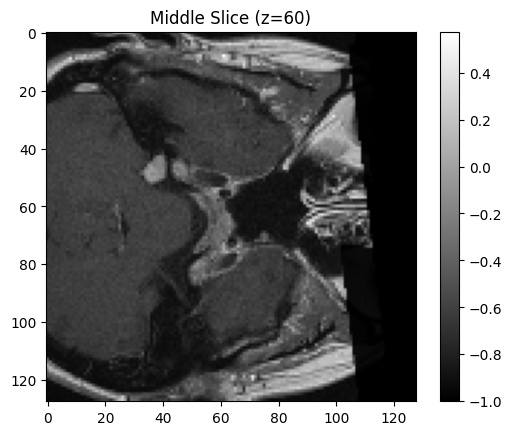

: 

In [48]:
import torch
import matplotlib.pyplot as plt

# Example tensor
# x = torch.randn(64, 64, 64)

# Get middle slice along the last dimension (axis=2)
# mid_index = b.shape[2] // 2
mid_index = 60
slice_2d = b[:, :, mid_index]

# Plot
plt.imshow(slice_2d.numpy(), cmap="gray")
plt.title(f"Middle Slice (z={mid_index})")
plt.colorbar()
plt.show()
